In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import math
import platform

pd.set_option('display.float_format',"{:.2f}".format)

# OS에 따라 다른 폰트 지정
if platform.system() == 'Darwin':   # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:  # Linux (예: Colab, Ubuntu)
    plt.rcParams['font.family'] = 'NanumGothic'

In [27]:
df = pd.read_csv('../공유/final_cleaned_airbnb.csv')
df.shape

(19861, 60)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19861 entries, 0 to 19860
Data columns (total 60 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   name                                          19861 non-null  str    
 1   host_since                                    19842 non-null  str    
 2   host_response_time                            19861 non-null  str    
 3   host_acceptance_rate                          19861 non-null  str    
 4   neighbourhood_cleansed                        19861 non-null  str    
 5   neighbourhood_group_cleansed                  19861 non-null  str    
 6   property_type                                 19861 non-null  str    
 7   room_type                                     19861 non-null  str    
 8   accommodates                                  19861 non-null  int64  
 9   bathrooms                                     19861 non-null  float64
 1

In [29]:
df.columns.tolist()

['name',
 'host_since',
 'host_response_time',
 'host_acceptance_rate',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'has_availability',
 'availability_30',
 'availability_60',
 'availability_90',
 'availability_365',
 'number_of_reviews',
 'number_of_reviews_ltm',
 'number_of_reviews_l30d',
 'availability_eoy',
 'number_of_reviews_ly',
 'estimated_occupancy_l365d',
 'estimated_revenue_l365d',
 'first_review',
 'last_review',
 'review_scores_rating',
 'review_scores_accuracy',
 'review_scores_cleanliness',
 'review_scores_checkin',
 'review_scores_communication',
 'review_scores_location',
 'review_scores_value',
 'license',
 'instant_bookable',
 'calculated_host_lis

In [30]:
#추정 매출 공식 검증 : 매출 = 가격 * 점유율
df['clac_revenue'] = df['price'] * df['estimated_occupancy_l365d']
(df['clac_revenue'] - df['estimated_revenue_l365d']).describe()

count   19861.00
mean        0.00
std         0.00
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
dtype: float64

In [31]:
# 계산된 매출과 추정 매출은 100% 일치
(df['clac_revenue'] == df['estimated_revenue_l365d']).mean()

np.float64(1.0)

In [32]:
#점유율 = 숙소가 1년 중 얼마나 예약되어 있었는가?
df['occupancy_rate'] = df['estimated_occupancy_l365d'] / 365
df['occupancy_rate'].describe()
#에어비앤비 평균 점유율은 약 17%

count   19861.00
mean        0.17
std         0.25
min         0.00
25%         0.00
50%         0.00
75%         0.33
max         0.70
Name: occupancy_rate, dtype: float64

### estimated_revenue_l365d=price×estimated_occupancy_l365d
    - 최근 1년 기준 추정 매출 = 최근 1년동안 예약된 일수 * 1박 요금(price)
- revenue는 독립적인 정보가 아님 (새로운 정보X)
- 가설1 : 가격이 높으면 점유율이 떨어질 것이다.
    - 산점도를 통해 가격이 높아질수록 점유율이 낮아지는 경향이 일부 관찰되었다.
    - 데이터 분포가 넓고 가격이 낮은 숙소에서도 점유율이 낮은 사례가 다수 존재하여,
    - 가격만으로 점유율을 충분히 설명하기는 어려운 것으로 판단된다.

- >추가 관찰 :뉴욕 에어비앤비 숙소의 평균 점유율은 약 17% 수준으로 나타났다. 이는 전체 숙소 중 상당수가 연중 낮은 예약률을 보이고 있음을 의미한다.

### 분석 구조 정의
- 1. price = 호스트가 조정 가능한 변수(1박 숙소 요금) -> 전략 변수로 채택
- 2. occupancy = 시장 수요 결과 -> 예측 대상으로 설정
- 3. revenue = price*occupancy -> 최종 성과로 설정 
> 점유율을 설명하는 요인을 찾고, 가격과 결합하여 수익을 평가한다

<Axes: xlabel='price', ylabel='occupancy_rate'>

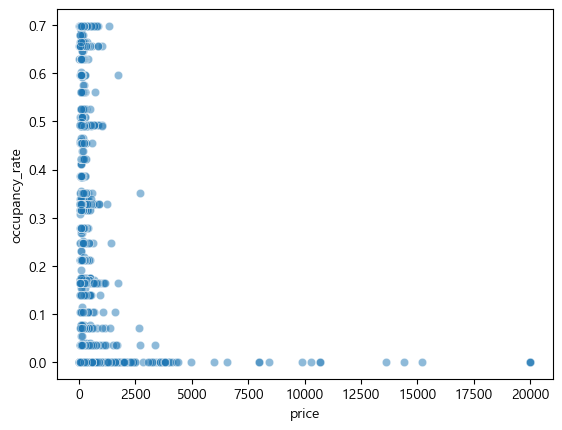

In [33]:
#가격과 점유율의 관계 확인
sns.scatterplot(
    data = df, 
    x= 'price',
    y= 'occupancy_rate',
    alpha = 0.5
)
#인사이트1 : price<1000 구간에 많이 몰려있음을 확인
#인사이트2 : 가격이 높아질수록 점유율이 낮아지는 경향이 있음
#인사이트3 : 고가 숙소의 경우 점유율이 낮거나 예약이 거의 없는 사례도 일부 관찰
#인사이트4 : 낮은 가격의 숙소에서도 점유율이 낮은 사례가 다수 존재하여 가격만으로 점유율이 결정되지는 않는 것으로 보임

In [34]:
#예약이 없는 숙소의 비율 ---> 1년간 예약 건수 0
(df['estimated_occupancy_l365d'] == 0).mean()

np.float64(0.5872816071698304)

In [35]:
#점유율 최대 약 70%
df['occupancy_rate'].max()

np.float64(0.6986301369863014)

### 페르소나 기반 모델 만들기
- 1. 인기요인 / 점유율 관계 분석
    - 목표: 어떤 요인이 점유율에 영향을 주는지 확인하는 것
        - 리뷰수/평점
        - 숙소 규모(room_capacity)
        - 지역/건물용도(숙소타입)
        - 운영옵션 : 즉시예약가능여부, 라이센스 등록 여부 등
- 2. 세그먼트별 성과 지표 만들기
    - neighbourhood_cleansed*room_type
        - 계산 지표(파생컬럼): 
            - median_price
            - median_occupancy_rate
            - median_revenue
            - listing_count -> 공급량
        - 블루오션 or 레드오션 구분
- 3. 초기 투자금 기준 수익 시뮬레이션 
    - 1. 투자금 시나리오 설정 | 소규모: 10,000 | 대규모: 30,000
    - 2. 월 예상 매출 = median_price * median_occupancy_rate * 30(일 수)
    - 3. 비용 = 월 매출 * 20~30%
    - 4. 순수익 = 월 매출 - 비용
    - 5. 초기 투자금 회수 기간 = 초기 투자금 / 순수익(월)
- 4. 페르소나 입력 기반 추천 시스템 설계
    - 목표: 호스트가 원하는 조건 입력 -> 추천 결과 제공
        - 입력: 운영 형태, 숙소 타입, 수용 인원, 옵션
        - 데이터 필터링: 세그먼트별 조건 매칭
        - 성과 계산: median_price, median_occupancy, median_revenue, 경쟁률(listing_count)
        - 추천 매물 TOP 5 -> 시장 포지션(블루|레드) 포함
        

In [36]:
df['property_regulation_type'].value_counts()

property_regulation_type
Residential_long_term     17245
Residential_short_term     1590
Hotel                      1026
Name: count, dtype: int64

[자치구별 공급량 vs 점유율 통계]
                              listing_count  avg_reviews
neighbourhood_group_cleansed                            
Manhattan                              9125         0.48
Brooklyn                               6585         0.71
Queens                                 3054         0.95
Bronx                                   814         0.65
Staten Island                           283         0.79


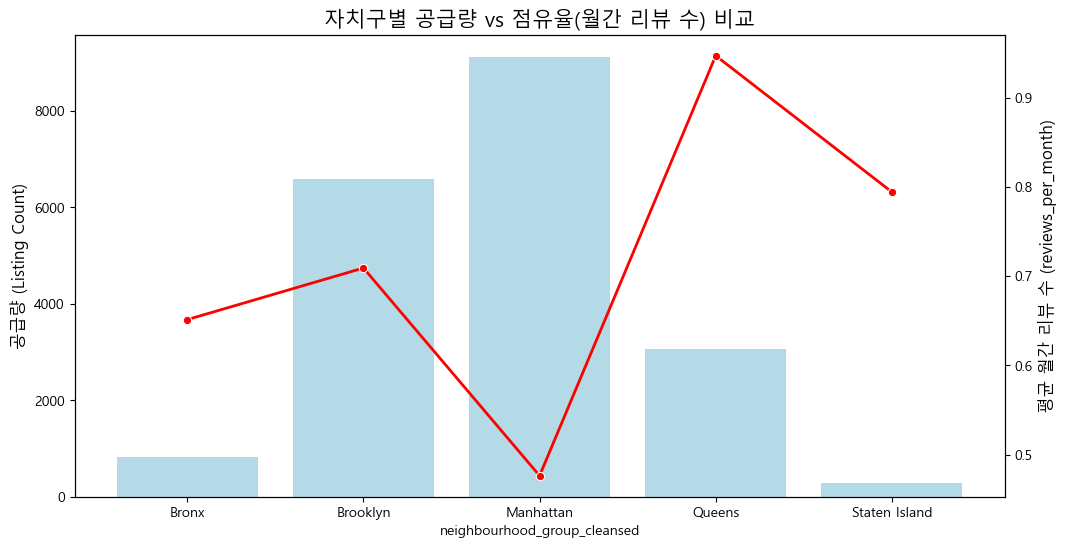

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

#자치구(Borough)별 공급량(전체 행 개수)과 평균 월간 리뷰 수 계산
# .size()를 쓰면 컬럼명 상관없이 그룹별 개수를 바로 셀 수 있음
borough_stats = df.groupby('neighbourhood_group_cleansed').agg(
    listing_count=('neighbourhood_group_cleansed', 'size'),
    avg_reviews=('reviews_per_month', 'mean')
)

print("[자치구별 공급량 vs 점유율 통계]")
print(borough_stats.sort_values(by='listing_count', ascending=False))

#시각화: 공급량(막대)과 점유율(선) 합치기
fig, ax1 = plt.subplots(figsize=(12, 6))

#왼쪽: 공급량(막대그래프)
sns.barplot(x=borough_stats.index, y=borough_stats['listing_count'], ax=ax1, color='skyblue', alpha=0.7)
ax1.set_ylabel('공급량 (Listing Count)', fontsize=12)

#오른쪽: 점유율(꺾은선그래프)
ax2 = ax1.twinx()
sns.lineplot(x=borough_stats.index, y=borough_stats['avg_reviews'], ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('평균 월간 리뷰 수 (reviews_per_month)', fontsize=12)

plt.title('자치구별 공급량 vs 점유율(월간 리뷰 수) 비교', fontsize=15)
plt.show()

In [54]:
def recommend_investor(df, persona, initial_investment, top_n=5):
    # 1. 조건 필터링
    filtered = df[
        (df['property_regulation_type'] == persona['property_regulation_type']) &
        (df['neighbourhood_group_cleansed'] == persona['neighbourhood_group_cleansed'])
    ]
    if filtered.empty:
        print("조건 수정 필요")
        return pd.DataFrame()
    
    # 2. 세그먼트 후보 컬럼
    segment_cols = ['number_of_reviews', 'number_of_reviews_ly', 'number_of_reviews_ltm', 'log_reviews', 
                    'recent_activity']
    
    # 3. 세그먼트별 성과 지표 계산
    segment_summary = filtered.groupby(['room_type', 'accommodates']).agg(
        median_price=('price', 'median'),
        median_occupancy_rate=('occupancy_rate', 'median'),
        median_revenue=('estimated_revenue_l365d', 'median'),
        listing_count=('price', 'count'),
        **{col: (col, 'median') for col in segment_cols}
    ).reset_index()
    
    # 4. 블루오션/레드오션 판단
    listing_median = segment_summary['listing_count'].median()
    revenue_median = segment_summary['median_revenue'].median()
    
    def ocean(row):
        if row['listing_count'] >= listing_median and row['median_revenue'] >= revenue_median:
            return '레드오션'
        elif row['listing_count'] < listing_median and row['median_revenue'] >= revenue_median:
            return '블루오션'
        else:
            return '기타'
    
    segment_summary['market_position'] = segment_summary.apply(ocean, axis=1)
    
    # 5. 수익 계산
    segment_summary['monthly_revenue'] = segment_summary['median_price'] * segment_summary['median_occupancy_rate'] * 30
    segment_summary['estimated_cost'] = segment_summary['monthly_revenue'] * 0.25   # 비용 25% 가정
    segment_summary['net_profit'] = segment_summary['monthly_revenue'] - segment_summary['estimated_cost']
    segment_summary['months_to_recover'] = initial_investment / segment_summary['net_profit']
    
    # 6. TOP N 추천
    top_segments = segment_summary.sort_values(by='net_profit', ascending=False).head(top_n)
    
    return top_segments

In [57]:
# 사용자 입력으로 persona 만들기
def create_persona():
    print("=== 투자자 페르소나 입력 ===")
    property_regulation_type = input("운영 형태 입력 (Residential_short_term/Residential_long_term/Hotel): ")
    room_type = input("숙소 타입 입력 (Entire home/apt, Private room, Hotel room 등): ")
    accommodates_min = int(input("최소 수용 인원 입력: "))
    neighbourhood_group_cleansed = input("동네 입력 (Manhattan, Brooklyn, Queens, Bronx, Staten Island): ")
    
    # 딕셔너리로 저장
    persona = {
        'property_regulation_type': property_regulation_type,
        'room_type': room_type,
        'accommodates_min': accommodates_min,
        'neighbourhood_group_cleansed': neighbourhood_group_cleansed
    }
    
    return persona

# 사용 예시
persona = create_persona()
initial_investment = int(input("초기 투자금 입력: "))

recommend_investor(df, persona, initial_investment, top_n=10)

=== 투자자 페르소나 입력 ===


,room_type,accommodates,median_price,median_occupancy_rate,median_revenue,listing_count,number_of_reviews,number_of_reviews_ly,number_of_reviews_ltm,log_reviews,recent_activity,market_position,monthly_revenue,estimated_cost,net_profit,months_to_recover
8,Entire home/apt,9,208.00,0.35,14535.00,2,25.00,3.00,2.50,3.21,0.00,블루오션,2179.73,544.93,1634.79,6.12
1,Entire home/apt,2,99.50,0.00,0.00,118,6.00,0.00,0.00,1.95,0.00,레드오션,0.00,0.00,0.00,inf
0,Entire home/apt,1,57.00,0.00,0.00,4,0.00,0.00,0.00,0.00,0.00,레드오션,0.00,0.00,0.00,inf
3,Entire home/apt,4,113.50,0.00,0.00,72,7.00,0.00,0.00,2.08,0.00,레드오션,0.00,0.00,0.00,inf
4,Entire home/apt,5,122.50,0.00,0.00,20,10.00,0.00,0.00,2.33,0.00,레드오션,0.00,0.00,0.00,inf
5,Entire home/apt,6,185.00,0.00,0.00,20,8.50,0.00,0.00,2.24,0.00,레드오션,0.00,0.00,0.00,inf
2,Entire home/apt,3,120.00,0.00,0.00,33,6.00,0.00,0.00,1.95,0.00,레드오션,0.00,0.00,0.00,inf
6,Entire home/apt,7,199.00,0.00,0.00,5,19.00,0.00,0.00,3.00,0.00,레드오션,0.00,0.00,0.00,inf
7,Entire home/apt,8,162.50,0.00,0.00,10,10.50,0.00,0.00,2.44,0.00,레드오션,0.00,0.00,0.00,inf
9,Entire home/apt,10,280.00,0.00,0.00,4,0.50,0.00,0.00,0.35,0.00,레드오션,0.00,0.00,0.00,inf
